<div style="background:linear-gradient(135deg,#0c4a6e 0%,#0369a1 55%,#7dd3fc 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#bae6fd;font-weight:700;text-transform:uppercase">Chapter 200 &middot; Capstone 37 &middot; Intermittent Demand</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Spare Parts</div>
  <div style="font-size:15px;color:#bae6fd;max-width:820px;line-height:1.6">Sixty part numbers, three years, and no demand at all in three weeks out of five. The percentage error the warehouse reports cannot be computed on most of its own data, and the forecast that scores best would empty the shelves.</div>
</div>

In [1]:
import numpy as np, pandas as pd, warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
SK, DK, LT, MUT, GD, RD = "#0369a1", "#0c4a6e", "#7dd3fc", "#94a3b8", "#047857", "#dc2626"

BASE_URL = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-intermittent-demand-spare-parts.xlsx"
def load(sheet):
    try:    return pd.read_excel("../../data/" + fn, sheet_name=sheet)
    except FileNotFoundError: return pd.read_excel(BASE_URL + fn, sheet_name=sheet)
raw   = load("Data")
notes = load("Notes")
LEAD, REVIEW, TARGET = 2, 1, 0.95        # weeks, weeks, fill rate
print("rows in the issues extract:", f"{len(raw):,}")
raw.head()

rows in the issues extract: 9,420


,week,part_no,family,units_issued
0,2023-01-02,P1000,filters,2
1,2023-01-02,P1001,filters,3
2,2023-01-02,P1002,filters,0
3,2023-01-02,P1003,filters,3
4,2023-01-02,P1004,filters,2


## Step 1 &middot; The brief

In [2]:
for line in notes.Notes.fillna(""):
    print(line)

PARTS WAREHOUSE ISSUES. Weekly units by part number, January 2023 to December 2025.

THE JOB. Set a stock level for every part for next year. The warehouse reviews stock weekly
and the supplier delivers two weeks after an order is placed, so each order has to cover three
weeks of demand. The service target agreed with the dealer network is a 95 percent FILL RATE:
95 units out of every 100 demanded should ship the day they are asked for.

WHAT MAKES THIS DIFFERENT. Most weeks, for most parts, nobody orders anything. Zero is not a
gap in the data, it is the most common observation in it. Any measure that divides by the
actual demand cannot be computed on those weeks, and any tool that reports one anyway has
quietly dropped them.

WHAT IS IN THE EXPORT, as it arrived:
 - the week of 6 May 2024 was extracted twice, so those sixty rows appear twice
 - part P1007 is written three ways across the years, one lower case and one with spaces
 - part P1019 shows -11 units in February 2024. That is

Three things in there set up everything that follows.

**Zero is an observation.** For most parts in most weeks nobody ordered anything, and that is the measurement, not a gap in it. Every method below has to be able to say zero and mean it.

**The deliverable is a stock level, not a forecast.** The warehouse orders weekly and the supplier takes two weeks, so each order covers a three-week window. What has to be decided is how many units to hold, and that is a question about the whole distribution of three-week demand rather than about its average.

**The target is a fill rate.** Ninety-five units in every hundred demanded should ship the day they are asked for. That is a different quantity from the probability of not running out, and Step 10 shows how far apart the two can be.

## Step 2 &middot; Cleaning

In [3]:
d = raw.copy()
d["part_no"] = d.part_no.str.strip().str.upper()
print(f"part numbers        {raw.part_no.nunique()} as written, {d.part_no.nunique()} after normalizing")

before = len(d)
d = d.drop_duplicates(subset=["week", "part_no"])
print(f"rows                {before:,} -> {len(d):,}   (the week of 6 May 2024 ran twice)")

d["week"] = pd.to_datetime(d.week)
odd = d[(d.units_issued < 0) | (d.units_issued >= 9999)]
print()
print("ROWS THAT ARE NOT ISSUES")
print(odd[["week", "part_no", "units_issued"]].to_string(index=False))
d.loc[d.units_issued < 0, "units_issued"] = 0        # a credited return is not negative demand
d.loc[d.units_issued >= 9999, "units_issued"] = 0    # a stock count is not an issue
print()
print("Both become zero: neither is evidence that a customer wanted a part that week.")

w = d.pivot(index="week", columns="part_no", values="units_issued").sort_index()
PARTS = list(w.columns)
Y = w.values.T.astype(int)
print(f"analysis frame      {len(PARTS)} parts x {len(w)} weeks, "
      f"{w.index.min():%b %Y} to {w.index.max():%b %Y}")

part numbers        62 as written, 60 after normalizing
rows                9,420 -> 9,360   (the week of 6 May 2024 ran twice)

ROWS THAT ARE NOT ISSUES
      week part_no  units_issued
2023-09-11   P1033          9999
2024-02-05   P1019           -11

Both become zero: neither is evidence that a customer wanted a part that week.
analysis frame      60 parts x 156 weeks, Jan 2023 to Dec 2025


**A credit note is not demand of minus eleven units, and a stock count is not a sale of nine thousand.** Left in place the first drags a part's average below what anyone ever ordered, and the second would dominate every statistic that part has. Both are set to zero rather than deleted, because the week itself is real and the correct reading of it is that nobody ordered anything.

## Step 3 &middot; First look

Sixty parts that will each get a stock level. Before choosing any method, what the demand actually looks like.

In [4]:
TRAIN = 104                                   # two years in, one year out
zero = (Y == 0).mean()
sizes = Y[Y > 0]

def sbc(y):
    """Syntetos-Boylan-Croston: average interval between orders, and how variable
    the order sizes are. The two cut-offs are the published ones."""
    nz = np.flatnonzero(y)
    if len(nz) < 2: return "dead", np.nan, np.nan
    p = len(y)/len(nz)
    s = y[nz]
    cv2 = (s.std(ddof=1)/s.mean())**2
    lab = ("smooth" if p < 1.32 and cv2 < 0.49 else "erratic" if p < 1.32
           else "intermittent" if cv2 < 0.49 else "lumpy")
    return lab, p, cv2

info = pd.DataFrame([sbc(Y[i]) for i in range(len(PARTS))],
                    columns=["class", "interval", "cv2"], index=PARTS)

print(f"{len(PARTS)} parts, {len(w)} weeks, {Y.sum():,} units issued in total")
print(f"  weeks with no demand at all      {zero:.1%}")
print(f"  order size when there is one     median {np.median(sizes):.0f}, "
      f"quartiles {np.percentile(sizes,25):.0f} to {np.percentile(sizes,75):.0f}, max {sizes.max():,}")
print(f"  weeks between orders             {info.interval.min():.1f} to {info.interval.max():.1f}")
print()
print("SYNTETOS-BOYLAN-CROSTON CLASSES")
for k, v in info["class"].value_counts().items():
    print(f"  {k:14s} {v:3d} parts")

60 parts, 156 weeks, 17,925 units issued in total
  weeks with no demand at all      61.0%
  order size when there is one     median 3, quartiles 1 to 5, max 222
  weeks between orders             1.0 to 9.2

SYNTETOS-BOYLAN-CROSTON CLASSES
  lumpy           26 parts
  intermittent    21 parts
  erratic          7 parts
  smooth           6 parts


**Three weeks in five have no demand at all, and the four classes are all occupied.** That matters because the classes behave differently: a part ordered almost every week in similar quantities is an ordinary forecasting problem, and a part ordered five times a year in wildly different quantities is not. Any method that treats all sixty the same is going to be wrong somewhere, and the classification says where to look.

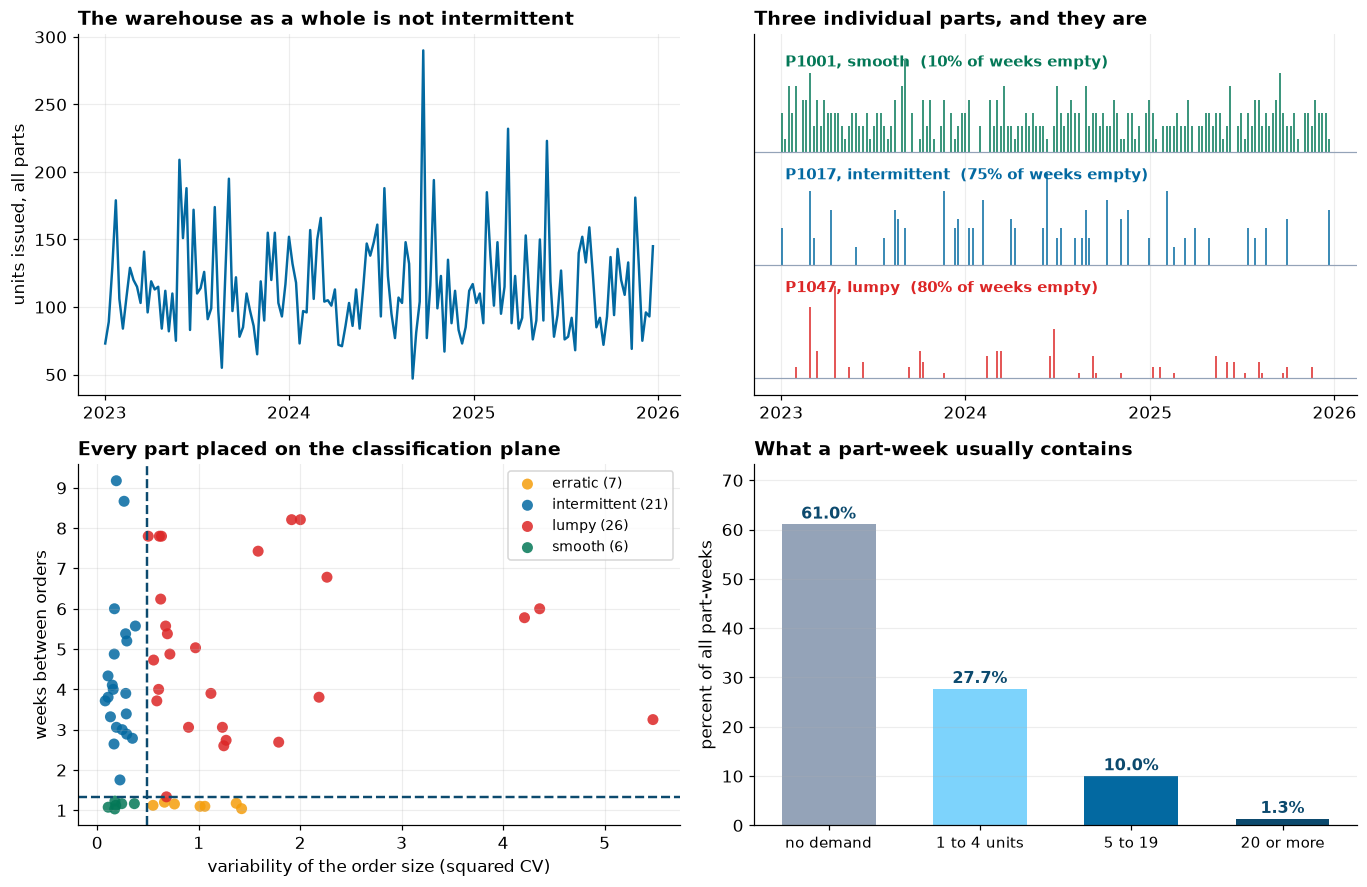

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12.6, 8.2))

YEARS = pd.to_datetime(["2023-01-01", "2024-01-01", "2025-01-01", "2026-01-01"])

ax = axes[0, 0]
tot = w.sum(1)
ax.plot(tot.index, tot.values, color=SK, lw=1.6)
ax.set_xticks(YEARS); ax.set_xticklabels([f"{y:%Y}" for y in YEARS])
ax.set_ylabel("units issued, all parts"); ax.set_title("The warehouse as a whole is not intermittent")

ax = axes[0, 1]
# one real part from each class, drawn as stems so the empty weeks read as empty
def representative(k):
    """The part closest to the middle of its own class on both axes."""
    g = info[info["class"] == k]
    z = (((g.interval - g.interval.median())/g.interval.std())**2
         + ((g.cv2 - g.cv2.median())/g.cv2.std())**2)
    return z.idxmin()
pick = [representative(k) for k in ["smooth", "intermittent", "lumpy"]]
for row, (p_, c_) in enumerate(zip(pick, [GD, SK, RD])):
    v = w[p_].values.astype(float)
    v = v/v.max()*0.82                       # each part gets its own band
    base = 2 - row
    ax.vlines(w.index, base, base + v, color=c_, lw=1.0)
    ax.axhline(base, color=MUT, lw=0.8)
    ax.text(w.index[1], base + 0.86, f"{p_}, {info.loc[p_,'class']}  "
            f"({int((w[p_] == 0).mean()*100)}% of weeks empty)",
            fontsize=9.5, fontweight="bold", color=c_, va="top")
ax.set_xticks(YEARS); ax.set_xticklabels([f"{y:%Y}" for y in YEARS])
ax.set_yticks([]); ax.set_ylim(-0.15, 3.05)
ax.set_title("Three individual parts, and they are")
ax.grid(axis="y", alpha=0)

ax = axes[1, 0]
ok = info.dropna(subset=["interval"])
cols = {"smooth": GD, "erratic": "#f59e0b", "intermittent": SK, "lumpy": RD}
for k, g in ok.groupby("class"):
    ax.scatter(g.cv2, g.interval, s=52, alpha=0.85, color=cols[k], edgecolor="none", label=f"{k} ({len(g)})")
ax.axvline(0.49, color=DK, lw=1.6, ls="--"); ax.axhline(1.32, color=DK, lw=1.6, ls="--")
ax.set_xlabel("variability of the order size (squared CV)")
ax.set_ylabel("weeks between orders")
ax.set_title("Every part placed on the classification plane")
ax.legend(fontsize=9, loc="upper right")

ax = axes[1, 1]
share = pd.Series({"no demand": zero, "1 to 4 units": ((Y > 0) & (Y <= 4)).mean(),
                   "5 to 19": ((Y >= 5) & (Y <= 19)).mean(), "20 or more": (Y >= 20).mean()})
ax.bar(range(len(share)), share.values*100,
       color=[MUT, LT, SK, DK], width=0.62)
for i, v in enumerate(share.values*100):
    ax.text(i, v + 1.2, f"{v:.1f}%", ha="center", fontsize=10.5, fontweight="bold", color=DK)
ax.set_xticks(range(len(share))); ax.set_xticklabels(share.index, fontsize=10)
ax.set_ylim(0, share.max()*100*1.20)
ax.set_ylabel("percent of all part-weeks")
ax.set_title("What a part-week usually contains")
ax.grid(axis="x", alpha=0)
plt.tight_layout(); plt.show()

**Top left:** added together the sixty parts make an ordinary, well-behaved series. Nothing about the warehouse total warns you that its components are not like it, which is why aggregate demand planning quietly hides this problem.

**Top right:** the same three years for one representative part from each of three classes, drawn so that an empty week reads as empty. These are the series that actually have to be forecast. The top one is an ordinary forecasting problem. The middle one is empty three weeks in four. The bottom one is emptier still, and when it does move the quantity swings from one unit to a dozen.

**Bottom left:** every part placed on the two axes that matter, with the published cut-offs drawn in. All four cells are occupied. **Bottom right:** three part-weeks in five contain nothing at all, and most of the rest contain a handful of units. Any measure that divides by the demand is undefined on the first bar, which is the largest one.

## Step 4 &middot; One of these parts is not intermittent, it is dead

Before any forecasting, a part that has stopped moving has to be separated from a part that moves rarely. They look identical in a spreadsheet and they need opposite decisions.

In [6]:
rows = []
for i, p_ in enumerate(PARTS):
    tr = Y[i, :TRAIN]; nz = np.flatnonzero(tr)
    if len(nz) < 3: continue
    gaps = np.diff(nz)
    silent = TRAIN - 1 - nz[-1]
    rows.append(dict(part=p_, weeks_silent=silent, mean_gap=gaps.mean(),
                     ratio=silent/gaps.mean()))
gap = pd.DataFrame(rows).sort_values("ratio", ascending=False).set_index("part")
print("HOW LONG SINCE THE LAST ORDER, AGAINST THAT PART'S OWN TYPICAL GAP")
display(gap.head(5).round(2))

DEAD = gap.index[0]
print(f"{DEAD} has been silent for {gap.weeks_silent.iloc[0]:.0f} weeks against a typical gap of "
      f"{gap.mean_gap.iloc[0]:.1f}.")
print(f"The next part on the list is at {gap.ratio.iloc[1]:.1f} times its own gap, so this is not a close call.")
print(f"In the holdout year {DEAD} was issued {Y[PARTS.index(DEAD), TRAIN:].sum()} units.")
LIVE = [p_ for p_ in PARTS if p_ != DEAD]
print(f"\n{DEAD} is superseded. It is excluded from everything below, leaving {len(LIVE)} parts to forecast.")

HOW LONG SINCE THE LAST ORDER, AGAINST THAT PART'S OWN TYPICAL GAP


,weeks_silent,mean_gap,ratio
part,,,
P1024,37,2.64,14.02
P1052,21,5.38,3.90
P1053,11,3.37,3.26
P1055,18,9.33,1.93
P1059,9,4.74,1.90


P1024 has been silent for 37 weeks against a typical gap of 2.6.
The next part on the list is at 3.9 times its own gap, so this is not a close call.
In the holdout year P1024 was issued 0 units.

P1024 is superseded. It is excluded from everything below, leaving 59 parts to forecast.


**Fourteen times its own typical gap, and the next part on the list is at four.** The rule generalizes: measure silence in units of the part's own inter-order interval rather than in weeks, because four weeks of quiet means nothing for a part ordered twice a year and a great deal for one ordered every fortnight.

This is a decision about the catalog rather than about forecasting, and it has to come first. Every method in Step 6 would have produced a small positive number for this part, the warehouse would have stocked it, and the stock would never have moved.

## Step 5 &middot; The measure the warehouse reports cannot be computed

The current planning tool reports a mean absolute percentage error. Percentage of what, on a week when nothing was demanded?

In [7]:
hold = Y[[PARTS.index(p_) for p_ in LIVE], TRAIN:]
n_cells = hold.size
n_zero = int((hold == 0).sum())
print(f"holdout year: {len(LIVE)} parts x {hold.shape[1]} weeks = {n_cells:,} part-weeks")
print(f"  of those, {n_zero:,} have zero demand ({n_zero/n_cells:.1%})")
print(f"  MAPE divides by the actual, so it is undefined on every one of them")
print()
print(f"  parts where MAPE can be computed on the whole year: "
      f"{int((hold > 0).all(axis=1).sum())} of {len(LIVE)}")
print(f"  share of the year a MAPE would actually be computed on: {(hold > 0).mean():.1%}")
print()
print("So a reported MAPE on this catalog is not a MAPE of the forecast. It is a MAPE of")
print("the weeks that happened to have demand, which are the easy weeks to be roughly right")
print("about and the minority of the data.")

holdout year: 59 parts x 52 weeks = 3,068 part-weeks
  of those, 1,867 have zero demand (60.9%)
  MAPE divides by the actual, so it is undefined on every one of them

  parts where MAPE can be computed on the whole year: 0 of 59
  share of the year a MAPE would actually be computed on: 39.1%

So a reported MAPE on this catalog is not a MAPE of the forecast. It is a MAPE of
the weeks that happened to have demand, which are the easy weeks to be roughly right
about and the minority of the data.


**A number was being reported every month that could not be computed on three fifths of its own input.** The tool did not fail loudly; it dropped the undefined rows and averaged what was left. The result is a measure of performance on the weeks where something happened, which systematically flatters nothing and misleads about everything: it says nothing at all about whether the forecast was right to expect quiet.

The replacement used from here is **MASE**, which divides by the average absolute change of the series itself rather than by the actual. It is defined on zeros, it is comparable across parts of very different sizes, and a value below 1 means the forecast beat a rule that just repeats last week.

## Step 6 &middot; Four forecasts

Two years of history for each part, one number out: the expected demand in an average week. Naive repeats last week. Simple exponential smoothing averages the whole series with geometrically decaying weights. Croston and SBA are built for this problem and are described properly in Step 8.

In [8]:
ALPHA = 0.10

def ses(y, a=ALPHA):
    l = float(y[0])
    for v in y[1:]:
        l = a*v + (1-a)*l
    return l

def croston(y, a=ALPHA, sba=False):
    """Smooth the order SIZE and the INTERVAL between orders separately, then divide."""
    nz = np.flatnonzero(y)
    if len(nz) == 0: return 0.0
    z, q, last = float(y[nz[0]]), float(nz[0] + 1), nz[0]
    for t in nz[1:]:
        z = a*y[t] + (1-a)*z
        q = a*(t - last) + (1-a)*q
        last = t
    f = z/q
    return f*(1 - a/2) if sba else f          # Syntetos-Boylan bias correction

METHODS = {"naive": lambda y: float(y[-1]), "SES": ses,
           "Croston": lambda y: croston(y), "SBA": lambda y: croston(y, sba=True)}

res = []
for p_ in LIVE:
    i = PARTS.index(p_)
    tr, te = Y[i, :TRAIN].astype(float), Y[i, TRAIN:].astype(float)
    scale = np.mean(np.abs(np.diff(tr)))
    if scale == 0: continue
    for nm, fn in METHODS.items():
        f = fn(tr)
        res.append(dict(part=p_, cls=info.loc[p_, "class"], method=nm, fc=f,
                        mase=np.mean(np.abs(te - f))/scale))
B = pd.DataFrame(res)
ORDER = ["naive", "SES", "Croston", "SBA"]
tbl = B.groupby(["cls", "method"]).mase.mean().unstack()[ORDER]
tbl = tbl.reindex([c for c in ["smooth", "erratic", "intermittent", "lumpy"] if c in tbl.index])
tbl.loc["all parts"] = B.groupby("method").mase.mean()[ORDER]
print("MASE by class (below 1 beats repeating last week)")
display(tbl.round(3))

MASE by class (below 1 beats repeating last week)


method,naive,SES,Croston,SBA
cls,,,,
smooth,0.753,0.751,0.752,0.757
erratic,1.140,0.848,0.842,0.823
intermittent,0.850,0.901,0.945,0.929
lumpy,1.446,0.890,0.887,0.871
all parts,1.137,0.875,0.888,0.873


**SBA is best overall and the margin is thin.** It wins the erratic and lumpy classes, where sizes swing about and Croston's upward bias bites hardest. It loses the intermittent class to the naive rule and ties on the smooth parts, where there is very little intermittency to handle.

Set against that, the naive rule is the worst overall by a wide margin, which is worth noting because on the aggregate warehouse series it would have looked perfectly reasonable.

## Step 7 &middot; Why the race is so close

Three of the four land within two percent of one another, and that is not because the methods are similar. It is a property of the measure.

In [9]:
best_const = []
for p_ in LIVE:
    i = PARTS.index(p_)
    tr, te = Y[i, :TRAIN].astype(float), Y[i, TRAIN:].astype(float)
    scale = np.mean(np.abs(np.diff(tr)))
    if scale == 0: continue
    # the constant that minimizes mean absolute error is the median
    c = float(np.median(te))
    best_const.append(dict(part=p_, c=c, mase=np.mean(np.abs(te - c))/scale))
K = pd.DataFrame(best_const)

print("THE BEST POSSIBLE CONSTANT FORECAST, chosen with hindsight to minimize MAE")
print(f"  it is zero for {int((K.c == 0).sum())} of the {len(K)} parts")
print(f"  its mean MASE is {K.mase.mean():.3f}")
print()
print(f"  compare the four honest methods:")
for nm in ORDER:
    print(f"     {nm:9s} {B[B.method==nm].mase.mean():.3f}")
print()
print("A forecast of zero, everywhere, beats all four. That is not a discovery about")
print("forecasting. It is what happens when a measure built on absolute error meets a")
print("series whose median is zero: the error-minimizing answer is to predict nothing.")

THE BEST POSSIBLE CONSTANT FORECAST, chosen with hindsight to minimize MAE
  it is zero for 44 of the 59 parts
  its mean MASE is 0.622

  compare the four honest methods:
     naive     1.137
     SES       0.875
     Croston   0.888
     SBA       0.873

A forecast of zero, everywhere, beats all four. That is not a discovery about
forecasting. It is what happens when a measure built on absolute error meets a
series whose median is zero: the error-minimizing answer is to predict nothing.


**The error-minimizing forecast on this catalog is zero, and zero empties the warehouse.** Mean absolute error is minimized at the median of the distribution, and for a part ordered once a month the median week contains no demand at all. So any horse race scored on MAE or MASE will reward the method that leans lowest, and the winner of that race is a policy that never orders anything.

This is the same lesson as the metric section of the workflow opener, in its most extreme form. **The measure has to come from the decision.** The decision here is how many units to hold, and it is answered by a quantile of demand over the lead time, not by an average of weekly demand and not by the method that minimizes an error statistic.

## Step 8 &middot; What Croston and SBA are actually doing

Exponential smoothing on the raw series mixes two different things: how often somebody orders, and how much they order when they do. Croston's method estimates them separately.

In [10]:
i = PARTS.index("P1045")
y = Y[i, :TRAIN].astype(float)
nz = np.flatnonzero(y)
a = ALPHA
z, q, last = float(y[nz[0]]), float(nz[0] + 1), nz[0]
for t in nz[1:]:
    z = a*y[t] + (1-a)*z
    q = a*(t - last) + (1-a)*q
    last = t
print(f"P1045, class {info.loc['P1045','class']}, {len(nz)} orders in {TRAIN} weeks")
print(f"  smoothed order SIZE      {z:.2f} units")
print(f"  smoothed INTERVAL        {q:.2f} weeks")
print(f"  Croston forecast         {z/q:.3f} units per week")
print(f"  SBA forecast             {z/q*(1-a/2):.3f} units per week   "
      f"(the {a/2:.0%} bias correction)")
print(f"  SES on the raw series    {ses(y):.3f} units per week")
print()
print("The correction exists because a ratio of two smoothed estimates is biased upward:")
print("the expectation of size divided by interval is not the size divided by the expected")
print("interval. Syntetos and Boylan derived the factor; on this catalog it is worth")
print(f"{(B[B.method=='Croston'].mase.mean()-B[B.method=='SBA'].mase.mean()):.3f} MASE, and it is free.")

P1045, class lumpy, 25 orders in 104 weeks
  smoothed order SIZE      3.35 units
  smoothed INTERVAL        4.29 weeks
  Croston forecast         0.781 units per week
  SBA forecast             0.742 units per week   (the 5% bias correction)
  SES on the raw series    0.721 units per week

The correction exists because a ratio of two smoothed estimates is biased upward:
the expectation of size divided by interval is not the size divided by the expected
interval. Syntetos and Boylan derived the factor; on this catalog it is worth
0.014 MASE, and it is free.


## Step 9 &middot; The number the warehouse actually needs

A forecast of 0.34 units a week is never the demand in any week. What the warehouse orders against is a level: hold this many, top up weekly, and the supplier takes two weeks. So the quantity to get right is total demand over the three weeks an order has to cover, and specifically a high quantile of it.

In [11]:
WINDOW = LEAD + REVIEW

def order_up_to(part, weekly_forecast, quantile):
    """Level from the forecast, spread from the part's own history."""
    i = PARTS.index(part)
    tr = Y[i, :TRAIN].astype(float)
    lt = np.array([tr[t:t+WINDOW].sum() for t in range(len(tr)-WINDOW)])
    if lt.std() == 0: return max(0.0, weekly_forecast*WINDOW)
    z = np.quantile((lt - lt.mean())/lt.std(), quantile)
    return max(0.0, weekly_forecast*WINDOW + z*lt.std())

def simulate(part, S):
    """Weekly review, order-up-to S, two-week lead time. Returns fill rate and stock held."""
    i = PARTS.index(part)
    on_hand, pipe, served, wanted, held = S, [], 0.0, 0.0, []
    for t in range(TRAIN, Y.shape[1]):
        if len(pipe) >= LEAD: on_hand += pipe.pop(0)
        dmd = Y[i, t]
        ship = min(on_hand, dmd)
        on_hand -= ship; served += ship; wanted += dmd
        held.append(on_hand)
        pipe.append(max(0.0, S - (on_hand + sum(pipe))))
    return (served/wanted if wanted else 1.0), float(np.mean(held))

demo = "P1045"
f_sba = croston(Y[PARTS.index(demo), :TRAIN].astype(float), sba=True)
print(f"{demo}: SBA says {f_sba:.3f} units a week, so {f_sba*WINDOW:.2f} over the three-week window")
print(f"  {'quantile':>9s}{'order up to':>13s}{'fill rate':>12s}{'units held':>12s}")
for qq in [0.50, 0.80, 0.95]:
    S = order_up_to(demo, f_sba, qq)
    fr, hd = simulate(demo, S)
    print(f"  {qq:>9.2f}{S:>13.1f}{fr:>12.1%}{hd:>12.1f}")

P1045: SBA says 0.742 units a week, so 2.23 over the three-week window
   quantile  order up to   fill rate  units held
       0.50          0.6        9.6%         0.3
       0.80          3.6       44.8%         2.3
       0.95         12.6       84.6%        10.2


**The average is not a stock level.** Ordering to the middle of three-week demand fills fewer than one unit in ten for this part. That is not a broken calculation: half of all three-week windows fall above the middle, and in this kind of demand the ones that do fall a long way above. Everything past the middle is safety stock, and how much of it to hold is the decision the warehouse is actually making.

## Step 10 &middot; What moves the fill rate, and what does not

Run every live part through the policy, for each forecasting method and each service quantile, and score the year that was held back.

In [12]:
grid = []
for nm in ORDER:
    for qq in [0.50, 0.80, 0.90, 0.95, 0.98]:
        fr, hd = [], []
        for p_ in LIVE:
            i = PARTS.index(p_)
            tr = Y[i, :TRAIN].astype(float)
            if np.mean(np.abs(np.diff(tr))) == 0: continue
            S = order_up_to(p_, METHODS[nm](tr), qq)
            a_, b_ = simulate(p_, S)
            fr.append(a_); hd.append(b_)
        grid.append(dict(method=nm, q=qq, fill=np.mean(fr), held=np.mean(hd)))
G = pd.DataFrame(grid)
piv = G.pivot(index="q", columns="method", values="fill")[ORDER]
print("FILL RATE achieved, by method and service quantile")
display((piv*100).round(1))

spread_method = (piv.loc[0.95].max() - piv.loc[0.95].min())*100
spread_q = (piv["SBA"].max() - piv["SBA"].min())*100
print(f"at the 0.95 quantile, the four methods differ by {spread_method:.1f} points of fill rate")
print(f"holding the method fixed, moving the quantile moves it by {spread_q:.1f} points")
print(f"the quantile has {spread_q/max(spread_method,0.01):.0f} times the leverage of the method")

FILL RATE achieved, by method and service quantile


method,naive,SES,Croston,SBA
q,,,,
0.50,37.2,45.1,46.0,44.0
0.80,63.3,76.2,78.6,77.6
0.90,79.4,86.7,87.3,86.9
0.95,89.8,92.4,92.9,92.7
0.98,94.4,95.8,96.2,96.1


at the 0.95 quantile, the four methods differ by 3.0 points of fill rate
holding the method fixed, moving the quantile moves it by 52.1 points
the quantile has 17 times the leverage of the method


**The choice everyone argues about is worth three points of fill rate. The choice nobody discusses is worth fifty-two.** Croston against SBA against exponential smoothing, at the service level the business asked for, spans three points and most of that is the naive rule being poor. Moving the service quantile moves the fill rate across almost its whole range.

That is not an argument for picking a method carelessly. SBA is free and slightly better, so use it. It is an argument about where the attention belongs, and in most warehouses it is pointed at the forecasting method.

In [13]:
sba95 = G[(G.method == "SBA") & (G.q == 0.95)].iloc[0]
print(f"asking for the 0.95 quantile of lead-time demand delivered a fill rate of {sba95.fill:.1%}")
print()
print("THE SERVICE CURVE, SBA forecasts")
print(f"  {'quantile':>9s}{'fill rate':>12s}{'units held':>12s}{'extra stock per point':>23s}")
prev = None
for _, r in G[G.method == "SBA"].sort_values("q").iterrows():
    extra = "" if prev is None else f"{(r.held-prev.held)/max((r.fill-prev.fill)*100,1e-9):>22.2f}"
    print(f"  {r.q:>9.2f}{r.fill:>12.1%}{r.held:>12.1f}{extra:>23s}")
    prev = r

asking for the 0.95 quantile of lead-time demand delivered a fill rate of 92.7%

THE SERVICE CURVE, SBA forecasts
   quantile   fill rate  units held  extra stock per point
       0.50       44.0%         1.6                       
       0.80       77.6%         4.8                   0.09
       0.90       86.9%         7.6                   0.30
       0.95       92.7%        11.1                   0.61
       0.98       96.1%        19.7                   2.46


**Two things to take from the curve.** The first is that asking for a 0.95 quantile did not deliver a 95 percent fill rate. Those are different quantities: the quantile controls how often a replenishment cycle runs short, and the fill rate counts units. If the business has agreed a fill rate, the quantile has to be tuned until the simulation delivers it, not assumed to equal it.

The second is the shape. Each extra point of fill rate costs more stock than the one before it, and the last few points cost several times what the middle ones did. **That curve, not the forecast, is what a service-level conversation should be held over.**

## Step 11 &middot; The pictures

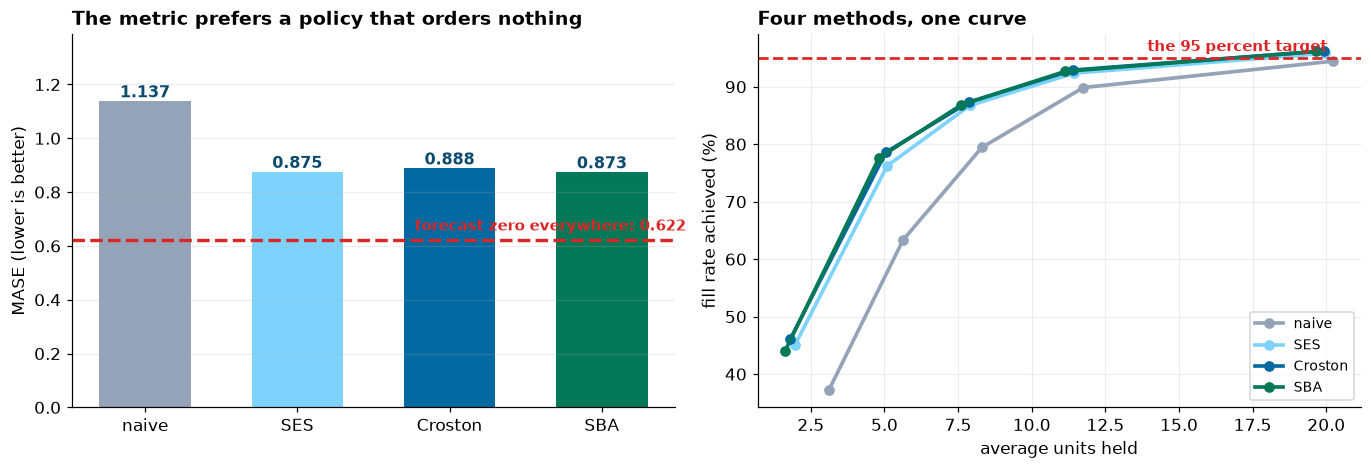

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))

ax = axes[0]
xp = np.arange(len(ORDER))
vals = [B[B.method == m_].mase.mean() for m_ in ORDER]
ax.bar(xp, vals, color=[MUT, LT, SK, GD], width=0.6)
for x_, v in zip(xp, vals):
    ax.text(x_, v + 0.015, f"{v:.3f}", ha="center", fontsize=10.5, fontweight="bold", color=DK)
ax.axhline(K.mase.mean(), color=RD, lw=2.2, ls="--")
ax.text(len(ORDER)-0.45, K.mase.mean() + 0.035,
        f"forecast zero everywhere: {K.mase.mean():.3f}", ha="right",
        fontsize=9.5, fontweight="bold", color=RD)
ax.set_xticks(xp); ax.set_xticklabels(ORDER)
ax.set_ylim(0, max(vals)*1.22)
ax.set_ylabel("MASE (lower is better)")
ax.set_title("The metric prefers a policy that orders nothing")
ax.grid(axis="x", alpha=0)

ax = axes[1]
for nm, c_ in zip(ORDER, [MUT, LT, SK, GD]):
    g = G[G.method == nm].sort_values("held")
    ax.plot(g.held, g.fill*100, color=c_, lw=2.4, marker="o", ms=6, label=nm)
ax.axhline(TARGET*100, color=RD, lw=1.8, ls="--")
ax.text(G.held.max()*0.99, TARGET*100 + 1.2, "the 95 percent target", ha="right",
        fontsize=9.5, fontweight="bold", color=RD)
ax.set_xlabel("average units held"); ax.set_ylabel("fill rate achieved (%)")
ax.set_title("Four methods, one curve")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout(); plt.show()

**Left:** the four methods, and the dashed line is the best constant forecast chosen with hindsight, which is zero for most parts. It beats all of them. A scoreboard on which "order nothing" is the winning entry is not measuring the thing the warehouse cares about.

**Right:** the same four methods plotted the way the decision is actually made, as stock held against service delivered. Three of the four lie almost on top of one another; the naive rule sits below them and needs noticeably more stock for the same service until the very top of the range. Where you sit along a curve is a business decision worth tens of points of fill rate. Which of the three upper curves you are on is worth almost nothing.

## Step 12 &middot; What this does not settle

**One alpha, never tuned.** Every smoothing constant here is 0.10, the conventional default for intermittent demand. Tuning it per part on a rolling origin would tighten the forecasts a little and would not move the picture on the right, which is the one that matters.

**The spread came from history, not from a model.** The order-up-to level takes its level from the forecast and its spread from the part's own past three-week windows. A part whose demand pattern is changing gets a stale spread, and nothing here would notice.

**Fill rate is not the only service measure.** Counting units treats one customer waiting for twenty parts the same as twenty customers waiting for one each. If the second is worse for the business, the target should not be a fill rate.

**Every part was treated as its own problem.** Parts that fail together, or that substitute for one another, break that assumption in opposite directions: the first raises the stock you need, the second lowers it. Nothing in this notebook shares information between parts, and for a catalog of sixty that is defensible. For a catalog of sixty thousand it is where the remaining gains are.